# Sunset Data Analysis

This notebook analyzes the UCSD Sunset community dataset (2023–present),
which contains detailed grade distributions per course section.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
root_dir = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "sunset_data.csv").exists()), None)
if root_dir is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.sunset_analysis import clean_sunset_analysis_frame, load_sunset_data, preview_sunset_frame
from src import sunset_descriptive as sd

df_raw = load_sunset_data(root_dir / 'data' / 'sunset_data.csv')

print(f'Sunset rows: {len(df_raw):,}')
print('Columns:', df_raw.columns.tolist())
preview_sunset_frame(df_raw, rows=3)



Sunset rows: 10,429
Columns: ['Submission time', 'User ID', 'Term', 'Course', 'Professor', 'Grade distribution', 'Recommend professor?']


,Term,Course,Grade distribution
0,Fall Qtr 2023,CSE 167,"A+:102, A:22, A-:11, B+:5, B:7, B-:6, C+:2, C:..."
1,Spring Qtr 2023,CSE 101,"A+:44, A:63, A-:45, B+:27, B:19, B-:11, C+:8, ..."
2,Spring Qtr 2023,CSE 110,"A+:0, A:17, A-:7, B+:9, B:6, B-:4, C+:1, C:0, ..."


## 2. Parse Grade Distribution

In [2]:
df_clean = clean_sunset_analysis_frame(df_raw)
print(f'Clean rows: {len(df_clean):,}')
print(f'Terms: {sorted(df_clean["Term_clean"].unique())}')
df_clean[['Course', 'Term_clean', 'GPA']].head(5)


Clean rows: 9,587
Terms: ['Fall 2019', 'Fall 2020', 'Fall 2021', 'Fall 2022', 'Fall 2023', 'Fall 2024', 'Fall 2025', 'SpecSumSes 2021', 'SpecSumSes 2022', 'SpecSumSes 2023', 'SpecSumSes 2024', 'SpecSumSes 2025', 'Spring 2020', 'Spring 2021', 'Spring 2022', 'Spring 2023', 'Spring 2024', 'Spring 2025', 'Sum Ses I 2020', 'Sum Ses I 2021', 'Sum Ses I 2022', 'Sum Ses I 2023', 'Sum Ses I 2024', 'Sum Ses I 2025', 'Sum Ses II 2020', 'Sum Ses II 2021', 'Sum Ses II 2022', 'Sum Ses II 2023', 'Sum Ses II 2024', 'Sum Ses II 2025', 'Winter 2020', 'Winter 2021', 'Winter 2022', 'Winter 2023', 'Winter 2024', 'Winter 2025']


,Course,Term_clean,GPA
0,CSE 167,Fall 2023,3.709756
1,CSE 101,Spring 2023,3.475652
2,CSE 110,Spring 2023,3.475556
3,PHYS 2C,Spring 2023,2.942857
4,CAT 125,Winter 2023,3.900000


## 3. Overall Grade Distribution (Sunset)

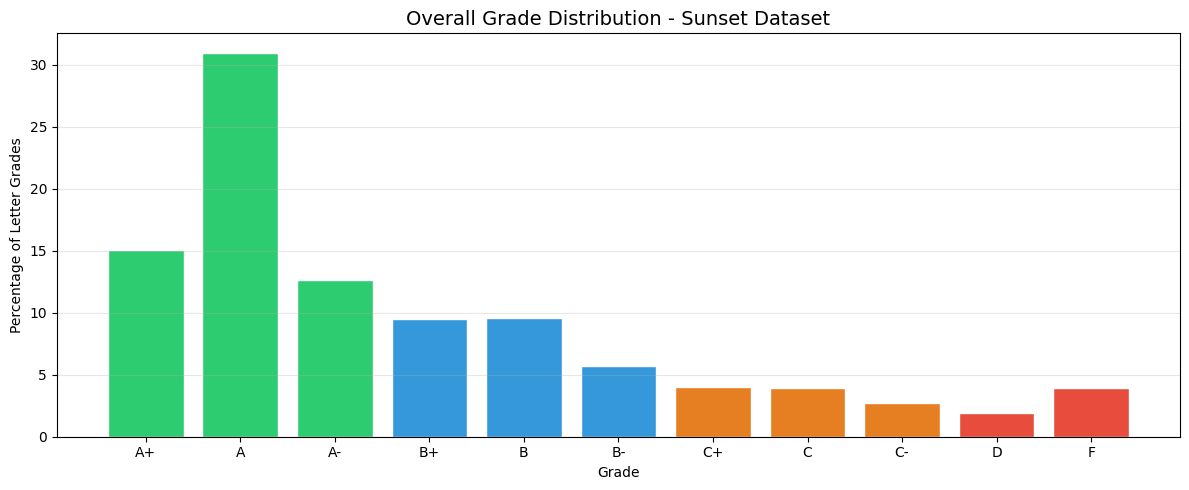

A+    15.07
A     30.99
A-    12.65
B+     9.49
B      9.55
B-     5.71
C+     4.03
C      3.92
C-     2.75
D      1.90
F      3.94
dtype: float64

In [3]:
grade_order = sd.available_grade_columns(df_clean)
grade_pct = sd.overall_grade_distribution(df_clean, grade_order)
sd.plot_overall_grade_distribution(grade_pct, 'figures/sunset_overall_dist.png')
grade_pct.round(2)


## 4. GPA by Department (Top 15)

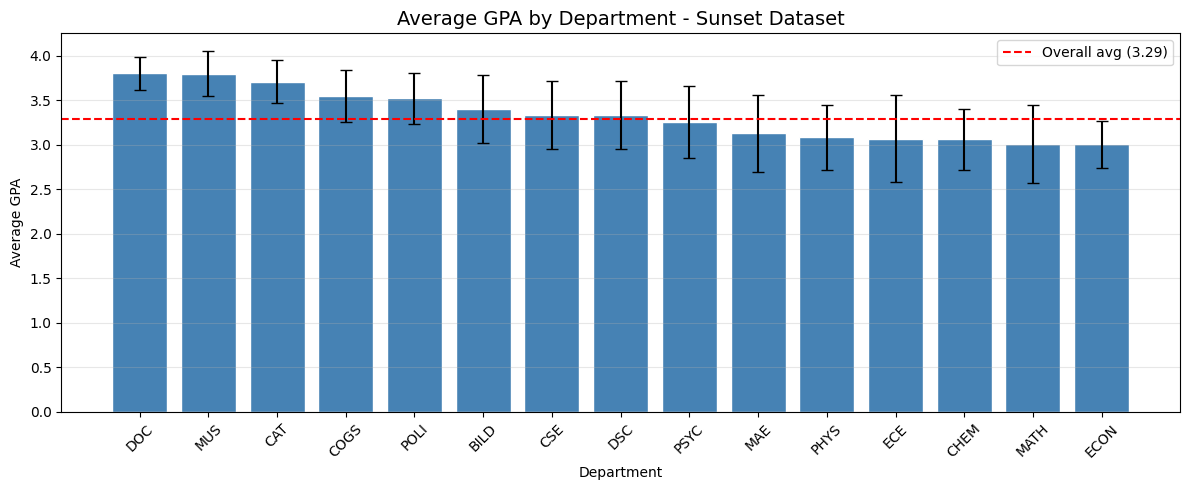

,mean,std,count
Department,,,
DOC,3.805,0.185,135
MUS,3.800,0.250,179
CAT,3.709,0.240,156
COGS,3.548,0.293,371
POLI,3.522,0.287,148
BILD,3.402,0.381,227
CSE,3.338,0.384,1950
DSC,3.334,0.381,147
PSYC,3.259,0.402,129


In [4]:
top15 = sd.top_departments_by_frequency(df_clean)
dept_gpa = sd.summarize_department_gpa(df_clean, top15)
sd.plot_department_gpa_summary(
    dept_gpa,
    overall_mean=df_clean['GPA'].mean(),
    save_path='figures/sunset_dept_gpa.png',
)
dept_gpa.round(3)


## 5. Grade Distribution by Term

                     mean  count
Term_clean                      
Fall 2019        3.182754     30
Fall 2020        3.393378    133
Fall 2021        3.271611    361
Fall 2022        3.336444    754
Fall 2023        3.275436   1238
Fall 2024        3.291452    770
Fall 2025        3.293925    429
SpecSumSes 2021  3.529569      9
SpecSumSes 2022  3.440482      6
SpecSumSes 2023  3.414056      6
SpecSumSes 2024  3.464633      3
SpecSumSes 2025  3.295023      5
Spring 2020      3.601163     35
Spring 2021      3.416479    135
Spring 2022      3.205222    371
Spring 2023      3.273665    771
Spring 2024      3.272474    555
Spring 2025      3.293380    537
Sum Ses I 2020   3.311578     17
Sum Ses I 2021   3.311634     20
Sum Ses I 2022   3.265635     48
Sum Ses I 2023   3.304200     79
Sum Ses I 2024   3.279632     49
Sum Ses I 2025   3.350908     53
Sum Ses II 2020  3.502912     13
Sum Ses II 2021  3.309842     18
Sum Ses II 2022  3.459502     71
Sum Ses II 2023  3.297563    116
Sum Ses II

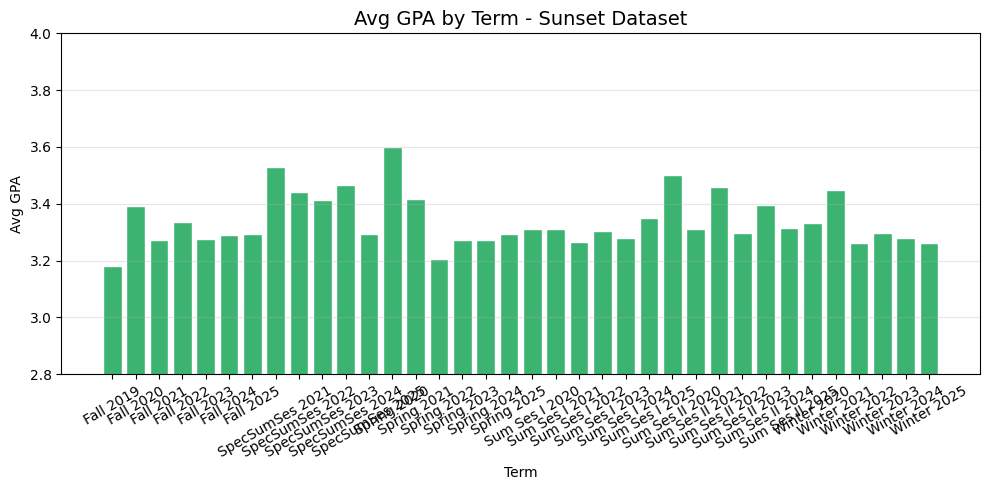

In [5]:
term_gpa = sd.summarize_term_gpa(df_clean)
print(term_gpa)
sd.plot_term_gpa(term_gpa, 'figures/sunset_term_gpa.png')


## 6. Grade Distribution Heatmap — Top Departments

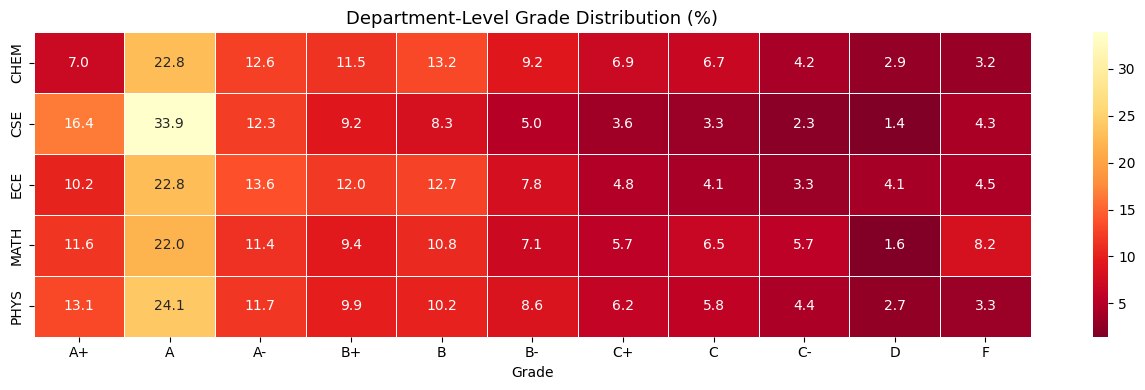

,A+,A,A-,B+,B,B-,C+,C,C-,D,F
Department,,,,,,,,,,,
CHEM,6.99,22.81,12.56,11.49,13.16,9.16,6.90,6.70,4.20,2.86,3.18
CSE,16.43,33.90,12.33,9.17,8.28,5.00,3.63,3.28,2.25,1.44,4.28
ECE,10.24,22.79,13.64,12.03,12.70,7.85,4.79,4.11,3.25,4.08,4.53
MATH,11.65,21.96,11.43,9.41,10.78,7.10,5.65,6.53,5.67,1.64,8.18
PHYS,13.12,24.05,11.75,9.93,10.16,8.58,6.16,5.79,4.44,2.71,3.32


In [6]:
FOCUS = sd.focus_departments(df_clean)
grade_order_plot = sd.available_grade_columns(df_clean)
heatmap_pct = sd.build_department_grade_heatmap(df_clean, FOCUS, grade_order_plot)
sd.plot_department_grade_heatmap(heatmap_pct, 'figures/sunset_grade_heatmap.png')
heatmap_pct.round(2)


## 7. Sunset vs CAPES — GPA Comparison

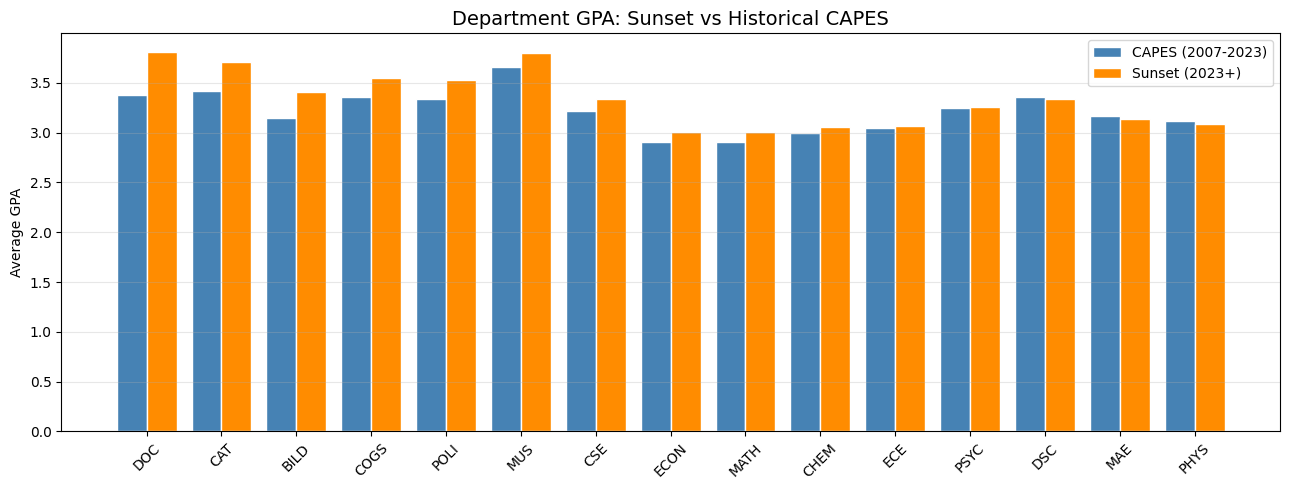

,CAPES (2007-2023),Sunset (2023+),Delta
Department,,,
DOC,3.381,3.805,0.424
CAT,3.413,3.709,0.297
BILD,3.150,3.402,0.253
COGS,3.356,3.548,0.192
POLI,3.335,3.522,0.188
MUS,3.655,3.800,0.145
CSE,3.212,3.338,0.126
ECON,2.900,3.007,0.106
MATH,2.908,3.008,0.100


In [7]:
comparison = sd.compare_sunset_and_capes_by_department(
    df_clean,
    pd.read_csv(root_dir / 'data' / 'capes_data.csv'),
    top15,
)
sd.plot_sunset_vs_capes(comparison, 'figures/sunset_vs_capes_dept.png')
comparison.round(3)
